In [ ]:
import sys
sys.path.append('../')
from pprint import pprint

import itertools
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from finite_groups import FiniteGroup
from induced_rep_solver import InducedRepSolver
from symchar.symchar import character_table

from groups.irrep_mats_generators import irreps_mats_Cn, irreps_mats_Sn

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x
def SQUARE(x): return x**2
def RELU_TANH(x): return RELU(x) + TANH(x)

# Utils

In [ ]:
def build_Cn(n):
    elements = list(range(n))
    def mult(a,b):
        return (a+b) % n

    return FiniteGroup(elements, mult)


def build_Sk(k):
    elements = list(itertools.permutations(range(k)))
    def mult(a,b):
        return tuple(a[i] for i in b)

    return FiniteGroup(elements, mult)


def build_product(G1,G2):

    elements = [(g,h) for g in G1.elements for h in G2.elements]
    def mult(x,y):

        g1,h1 = x
        g2,h2 = y

        return (
            G1.mult_func(g1,g2),
            G2.mult_func(h1,h2)
        )

    return FiniteGroup(elements, mult)


def build_H(k):
    perms = list(itertools.permutations(range(k-1)))
    H = []

    for p in perms:
        perm = list(range(k))
        for i in range(k-1):
            perm[i] = p[i]
        H.append((0,tuple(perm)))
    return H

# # Regular Representation
# def build_H(k):
#     """
#     H = {e} inside C_n × S_k
#     """
#     identity_perm = tuple(range(k))
#     return [(0, identity_perm)]

## Characters

In [13]:
def generate_partitions(n):
    def generate(n, max_part, current, result):
        if n == 0:
            result.append(tuple(current))
            return
        for i in range(min(max_part, n), 0, -1):
            generate(n - i, i, current + [i], result)

    result = []
    generate(n, n, [], result)
    return result

# def Sk_character_table(k):
#     char_table = np.array(character_table(k), dtype=object).T
#     partitions = generate_partitions(k)
#     labels = [''.join(map(str,p)) for p in partitions]

#     partition_map = {
#         tuple(sorted(p, reverse=True)): i
#         for i,p in enumerate(partitions)
#     }
#     return char_table, labels, partition_map

def Sk_character_table_map(G: FiniteGroup, k: int):
    """
    Character table for S_k using symchar.

    Returns a map:
        class_char_map[cls.representative] = character row
    """
    from symchar.symchar import character_table

    raw = np.array(character_table(k), dtype=object).T
    partitions = generate_partitions(k)
    labels = [''.join(map(str, p)) for p in partitions]
    partition_map = {
        tuple(sorted(p, reverse=True)): i
        for i, p in enumerate(partitions)
    }

    class_char_map = {}
    for cls in G.classes:
        rep = cls.representative
        part = cycle_type(rep)
        if part not in partition_map:
            raise ValueError(f"Cycle type {part} not found in the partition map.")
        class_char_map[rep] = [sp.sympify(x) for x in raw[partition_map[part]]]

    return class_char_map, labels, partition_map

def Cn_character_table(n, labels=None):
    table = []

    for g in range(n):
        row = [sp.exp(2 * sp.pi * sp.I * g * m / n) for m in range(n)]
        table.append(row)

    if labels is None:
        labels = [str(j) for j in range(n)]

    return np.array(table, dtype=object), labels

def cycle_type(perm):
    k = len(perm)
    seen = [False] * k
    parts = []

    for i in range(k):
        if not seen[i]:
            j = i
            length = 0
            while not seen[j]:
                seen[j] = True
                j = perm[j]
                length += 1
            parts.append(length)

    return tuple(sorted(parts, reverse=True))


def direct_prod_character_table(G,
                                Cn_table, Cn_labels,
                                Sk_table, Sk_labels,
                                Sk_partition_map=None):
    """
    Backwards-compatible:
      - Sk_table may be an old array indexed by partition index, or
      - Sk_table may be a dict mapping S_k class representatives -> character row.
    """
    labels = [rf"{c} ⊗ {s}" for c in Cn_labels for s in Sk_labels]
    class_char_dict = {}

    sk_is_map = isinstance(Sk_table, dict)

    for cls in G.classes:
        g, sigma = cls.representative
        cn_row = Cn_table[g]

        if sk_is_map:
            if sigma not in Sk_table:
                raise ValueError(f"S_k class representative {sigma} not found in Sk_table map.")
            sk_row = Sk_table[sigma]
        else:
            if Sk_partition_map is None:
                raise ValueError("Sk_partition_map is required when Sk_table is an array.")
            part = cycle_type(sigma)
            if part not in Sk_partition_map:
                raise ValueError(f"Cycle type {part} not found in partition map.")
            sk_row = Sk_table[Sk_partition_map[part]]

        row = [sp.simplify(chi * psi) for chi in cn_row for psi in sk_row]
        class_char_dict[cls.representative] = row

    return class_char_dict, labels

def direct_prod_irrep_mats(Cn_n, Sk_n, Cn_labels, Sk_labels):
    """
    Build product irrep matrices with labels matching direct_prod_character_table.
    For (g, sigma) in C_n x S_k:
        rho_{chi ⊗ psi}(g, sigma) = chi(g) * rho_psi(sigma)
    """
    Cn_irreps = irreps_mats_Cn(Cn_n)
    Sk_irreps = irreps_mats_Sn(Sk_n)

    out = {}

    for c in Cn_labels:
        if c not in Cn_irreps:
            raise ValueError(f"C_n irrep label {c} not found in irreps_mats_Cn.")
        for s in Sk_labels:
            if s not in Sk_irreps:
                raise ValueError(f"S_k irrep label {s} not found in irreps_mats_Sn.")

            label = f"{c} ⊗ {s}"
            rho_c = Cn_irreps[c]
            rho_s = Sk_irreps[s]

            rho_prod = {}
            for g in rho_c:
                for sigma in rho_s:
                    rho_prod[(g, sigma)] = sp.simplify(rho_c[g][0, 0] * rho_s[sigma])

            out[label] = rho_prod

    return out



def run(Cn, Sk, H, n, activation_fn,
        refine=False,
        regular=False,
        irrep_mats=None,
        interaction=False,
        figsize=(10, 10),
        show_kernel_inclusions=True,
        show_self_loops=False):

    G = build_product(Cn, Sk)

    solver = InducedRepSolver(G)
    if regular:
        solver.set_subgroup([G.identity])
    else:
        solver.set_subgroup(H)

    Cn_table, Cn_labels = Cn_character_table(n[0])
    Sk_char_map, Sk_labels, Sk_partition_map = Sk_character_table_map(Sk, n[1])

    class_char_map, labels = direct_prod_character_table(
        G,
        Cn_table, Cn_labels,
        Sk_char_map, Sk_labels,
        Sk_partition_map
    )

    solver.load_character_table(class_char_map, labels)

    if refine:
        if irrep_mats is None:
            irrep_mats = direct_prod_irrep_mats(n[0], n[1], Cn_labels, Sk_labels)
        solver.load_irrep_matrices(irrep_mats)

    solver.compute_projectors(refine=refine)

    if interaction:
        graph = solver.build_interaction_graph(activation_fn=activation_fn)
    else:
        graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    solver.visualise_interaction_graph(
        graph,
        group_name=rf"$C_{n[0]} \times S_{n[1]} \quad (\text{{{activation_fn.__name__}}})$",
        node_size=2200,
        show_self_loops=show_self_loops,
        show_kernel_inclusions=show_kernel_inclusions,
        figsize=figsize
    )

    return graph, solver


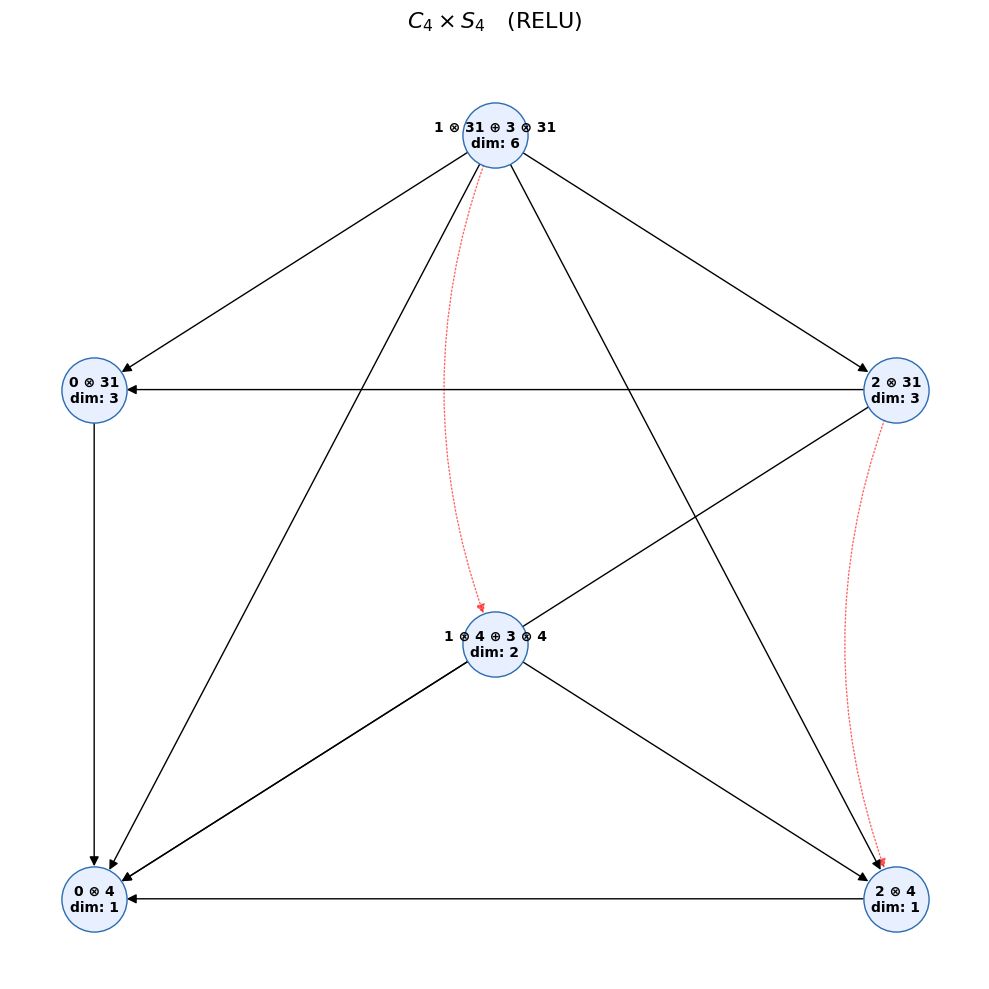

In [20]:
n = [4,4]

activation_fn = RELU
regular = False
refine = False
interction = False

Cn = build_Cn(n[0])
Sk = build_Sk(n[1])
H = build_H(n[1])

graph, solver = run(Cn, Sk, H, n, activation_fn, 
                    regular=regular, 
                    refine=refine, 
                    interaction=interction, 
                    figsize=(10,10),
                    show_self_loops=False)

<Axes: >

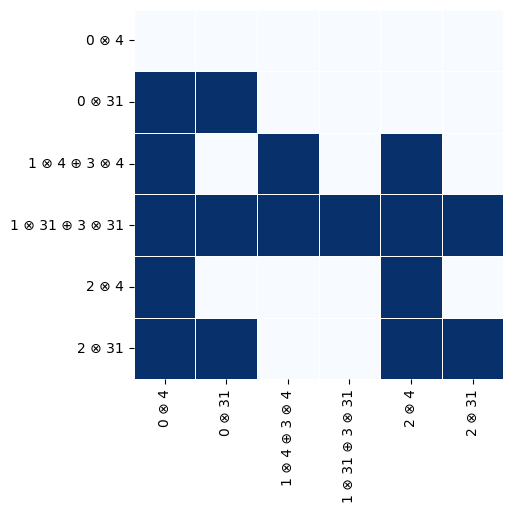

In [21]:
import pandas as pd
import seaborn as sns

nodes = list(graph.nodes())

A = nx.to_numpy_array(graph, nodelist=nodes).astype(int)

sns.heatmap(pd.DataFrame(A, index=nodes, columns=nodes), cbar=False, square=True, cmap="Blues", linewidths=0.5)

In [ ]:
col_ranges = {}
col_labels = []

start = 0
blocks = []

for label, Qblock in solver.Qblocks.items():
    r, c = Qblock.shape
    if r > 1:                      
        blocks.append(Qblock)

        end = start + c
        col_ranges[label] = (start, end)
        col_labels.extend([label] * c)
        start = end


Q = sp.Matrix(np.hstack(blocks))
Q_inv = Q.inv()


pprint(col_ranges)
# sp.Matrix([0,1,0,0,0,0,0,0]).T * Q_inv * (Q * sp.Matrix([0,0,0,0,1,1,0,0])).applyfunc(activation_fn)
Q_inv * (Q).applyfunc(activation_fn)

In [ ]:
# def run(n,k, activation=RELU, Cn_labels=None):

#     Cn = build_Cn(n)
#     Sk = build_Sk(k)

#     G = build_product(Cn,Sk)
#     H = build_H(k)

#     solver = InducedRepSolver(G)
#     solver.set_subgroup(H)

#     Sk_char_table, Sk_labels, Sk_partition_map = Sk_character_table(k)
#     Cn_char_table, Cn_labels = Cn_character_table(n, Cn_labels)
#     char_table, labels = direct_prod_character_table(G, Cn_char_table, Cn_labels, Sk_char_table, Sk_labels, Sk_partition_map)

#     solver.load_character_table(char_table, labels)
#     solver.compute_projectors(refine=False)

#     graph = solver.build_isotypic_graph(activation_fn=activation)

#     return graph, solver

In [ ]:
# graphs = {}
# n = 4
# activation_fn = RELU

# for i in range(1, n+1):
#     for j in range(1, n+1):
#         print(f"Computing C{i+1} x S{j+1}")
#         graphs[(i, j)] = run(i, j, activation=activation_fn)

# def create_svg_grid(graphs, n, filename="grid.svg"):

#     fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

#     for i in range(n):
#         for j in range(n):
#             ax = axes[i, j]

#             graph, solver = graphs[(i+1, j+1)]
#             solver.visualise_interaction_grid(graph, ax=ax, group_name=f"C{i+1} x S{j+1}")


#     plt.tight_layout()
#     fig.savefig(filename, format="svg")
#     plt.close(fig)


# create_svg_grid(graphs, n=n, filename=f"outputs/Regular_Cn_Sk_n={n}_{activation_fn.__name__}.svg")